In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target
X = df.drop("target",axis=1)
y = df["target"]


In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(data.target_names)
print(pd.Series(data.target).value_counts())

['malignant' 'benign']
1    357
0    212
Name: count, dtype: int64


In [4]:
cm = confusion_matrix(
    [0, 0, 1, 1],
    [0, 1, 1, 1],
    labels=[0, 1]
)

print(cm)

[[1 1]
 [0 2]]


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train,y_train) 
lr_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test,lr_pred,labels=[0,1])
print(cm)

[[41  1]
 [ 1 71]]


In [6]:
malignant_precision = precision_score(
    y_test,
    lr_pred,
    pos_label=0
)

malignant_recall = recall_score(
    y_test,
    lr_pred,
    pos_label=0
)

malignant_f1 = f1_score(
    y_test,
    lr_pred,
    pos_label=0
)

print("Malignant Precision:", malignant_precision)
print("Malignant Recall:", malignant_recall)
print("Malignant F1 Score:", malignant_f1)

Malignant Precision: 0.9761904761904762
Malignant Recall: 0.9761904761904762
Malignant F1 Score: 0.9761904761904762


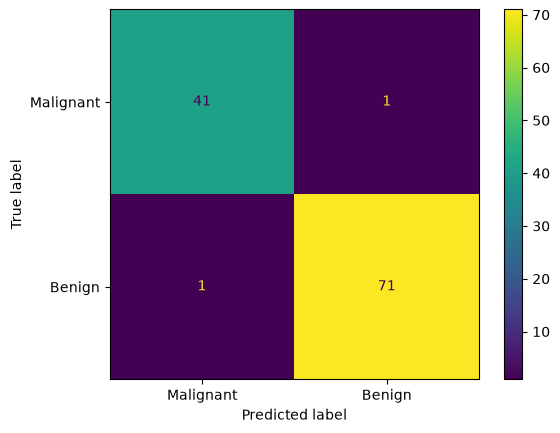

In [7]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.show()

In [8]:
probabilities = pipeline.predict_proba(X_test)

print(probabilities[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [9]:
malignant_proba = probabilities[:, 0]

print(malignant_proba[:10])

[9.99999941e-01 1.13351672e-05 9.93589175e-01 4.66491463e-01
 9.99999999e-01 7.83960163e-03 1.71746799e-05 9.99999436e-01
 9.99945684e-01 1.00000000e+00]


In [10]:
for threshold in [0.3, 0.5, 0.7]:

    custom_pred = np.where(
        malignant_proba >= threshold,
        0,
        1
    )

    cm = confusion_matrix(
        y_test,
        custom_pred,
        labels=[0, 1]
    )

    print(f"\nThreshold: {threshold}")
    print(cm)


Threshold: 0.3
[[41  1]
 [ 5 67]]

Threshold: 0.5
[[41  1]
 [ 1 71]]

Threshold: 0.7
[[40  2]
 [ 0 72]]


In [11]:
for threshold in [0.3, 0.5, 0.7]:

    custom_pred = np.where(
        malignant_proba >= threshold,
        0,
        1
    )

    precision = precision_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    recall = recall_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    f1 = f1_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


Threshold: 0.3
Precision: 0.8913043478260869
Recall: 0.9761904761904762
F1 Score: 0.9318181818181818

Threshold: 0.5
Precision: 0.9761904761904762
Recall: 0.9761904761904762
F1 Score: 0.9761904761904762

Threshold: 0.7
Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561
